In [434]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm
from scipy.stats import beta
from scr.mayflylib import mayflylib as mfl
from scr.mayfly_internal import mayfly_internal as mfi

In [2]:
data = np.load("photos_train.npz")

In [3]:
data.files

['Image', 'Date', 'Species', 'Multiple']

In [353]:
def standardize(image):
    b=6
    a = 0.05
    mean = np.mean(image)
    std = np.std(image)
    z = (image - mean) / std
    mask = np.sum(z, axis = 2)/3 > 0 
    z[mask] = 0
    p = norm.cdf(z)
    p = 1/(1+((a/(1-a))*(1-p)/p)**b)
    x = 255*beta.ppf(p,6,1)
    x = np.sum(x,axis = 2)/3
    x = x.astype(np.uint8)
    
    return x

In [392]:
N = 3

rng = np.random.default_rng(seed=50)
arr = np.arange(data["Image"].shape[0])
indexes = np.random.choice(arr, size=N, replace=False)

In [393]:
images = data["Image"][indexes]


In [394]:
standardized = np.array([standardize(image) for image in images])
image = np.concatenate(images,axis = 1)
standardized = np.concatenate(standardized,axis = 1)
standardized = np.stack([standardized] * 3, axis=-1)
together = np.concatenate((image,standardized),axis = 0)

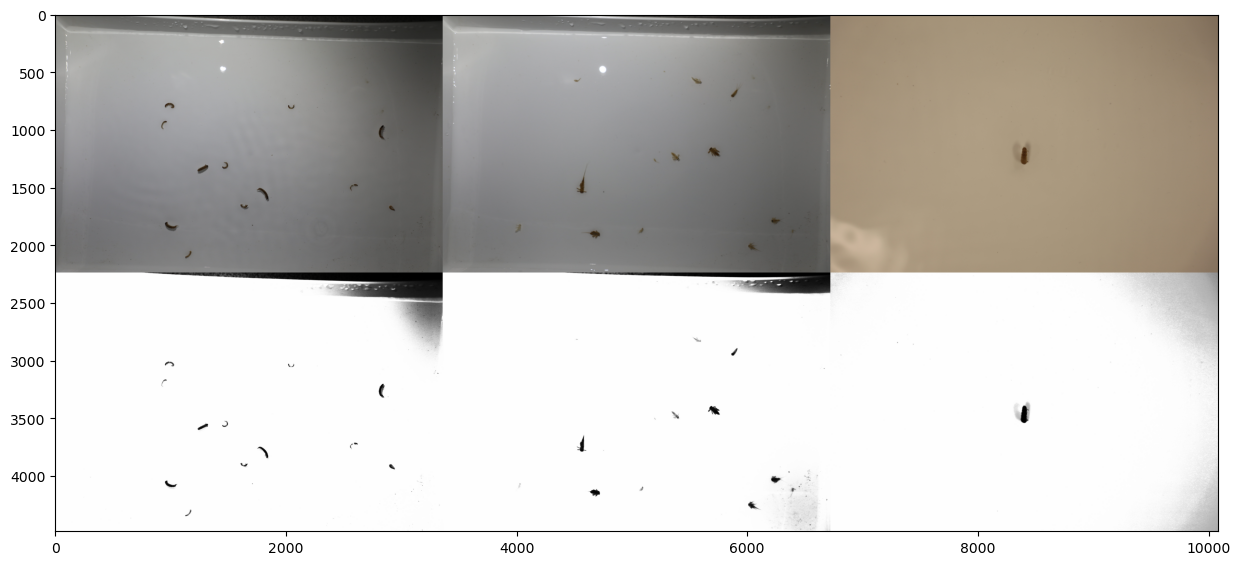

In [395]:
S = 15
plt.figure(figsize=(S, S*N))
plt.imshow(together)

TypeError: NB_predictions() missing 1 required positional argument: 'slice_factor'

In [425]:
mayflylib

<module 'scr.mayflylib.mayflylib' from '/Users/tcp59/Learning/Inverts Project/Macroinvertebrate-Classifier/scr/mayflylib/mayflylib.py'>